In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('housing.csv')
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [3]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
data.dropna(inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [7]:
from sklearn.model_selection import train_test_split

x = data.drop(['median_house_value'],axis=1)
y = data['median_house_value']


In [8]:
x_train , x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2, random_state=42
)

In [9]:
train_data = x_train.join(y_train)

# from sklearn.preprocessing import LabelEncoder
# encoder = LabelEncoder()
# train_data['ocean_proximity'] = encoder.fit_transform(train_data['ocean_proximity'])

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

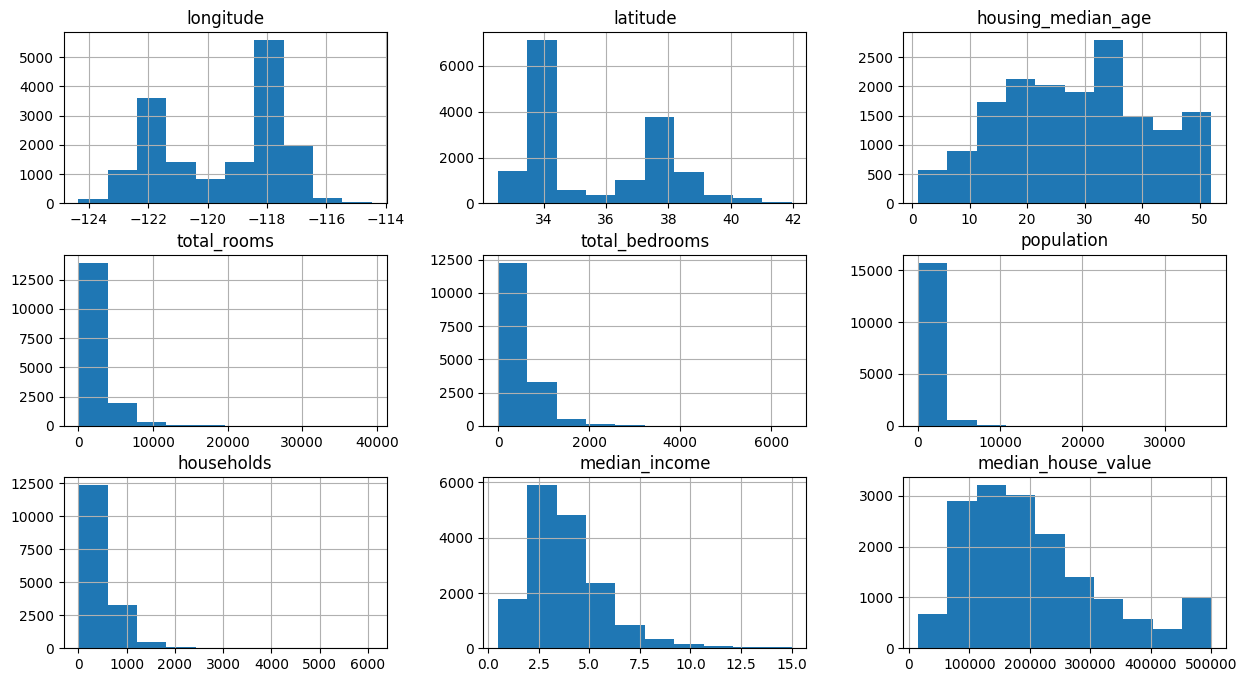

In [10]:
train_data.hist(figsize=(15,8))

so here we can see total_rooms, total_bedrooms, population, households have some highly skewed values

<Axes: >

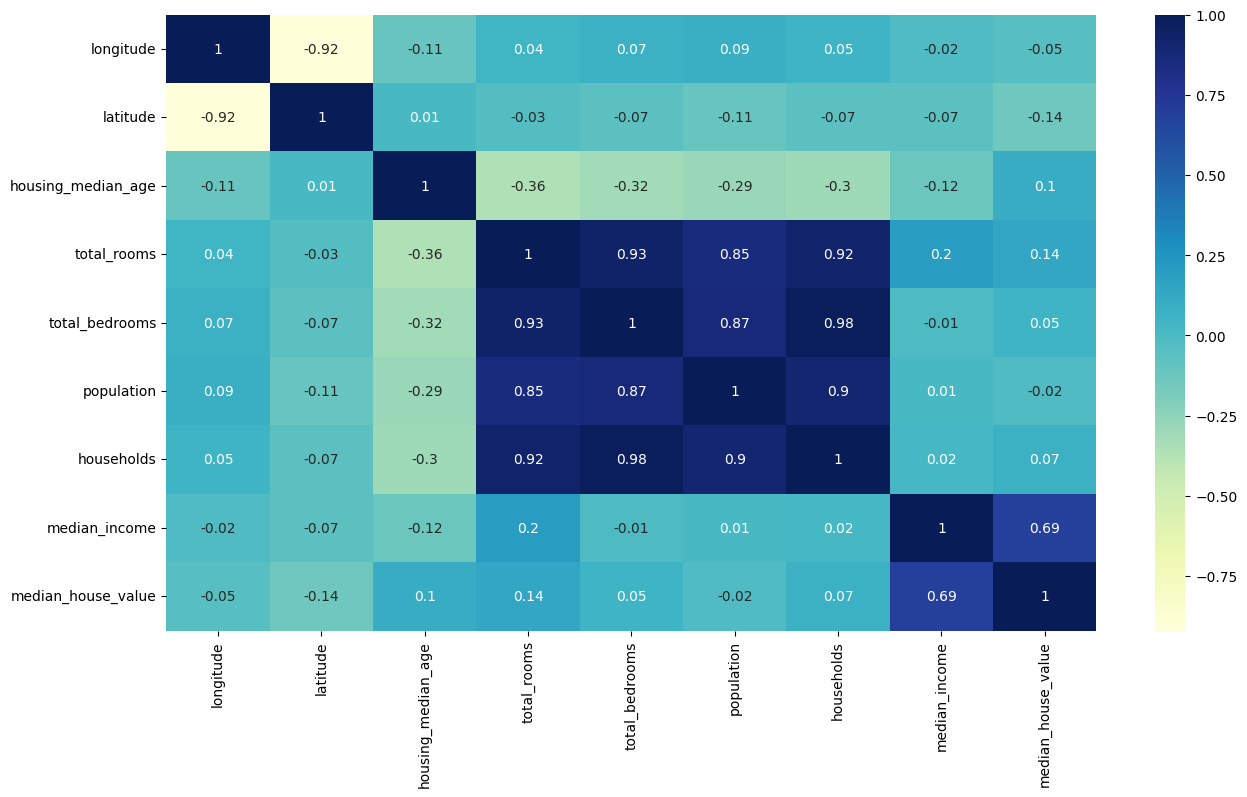

In [11]:
plt.figure(figsize=(15,8))
numeric_data = train_data.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_data.corr().round(2), annot=True, cmap='YlGnBu')

to reduce skewness

In [12]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

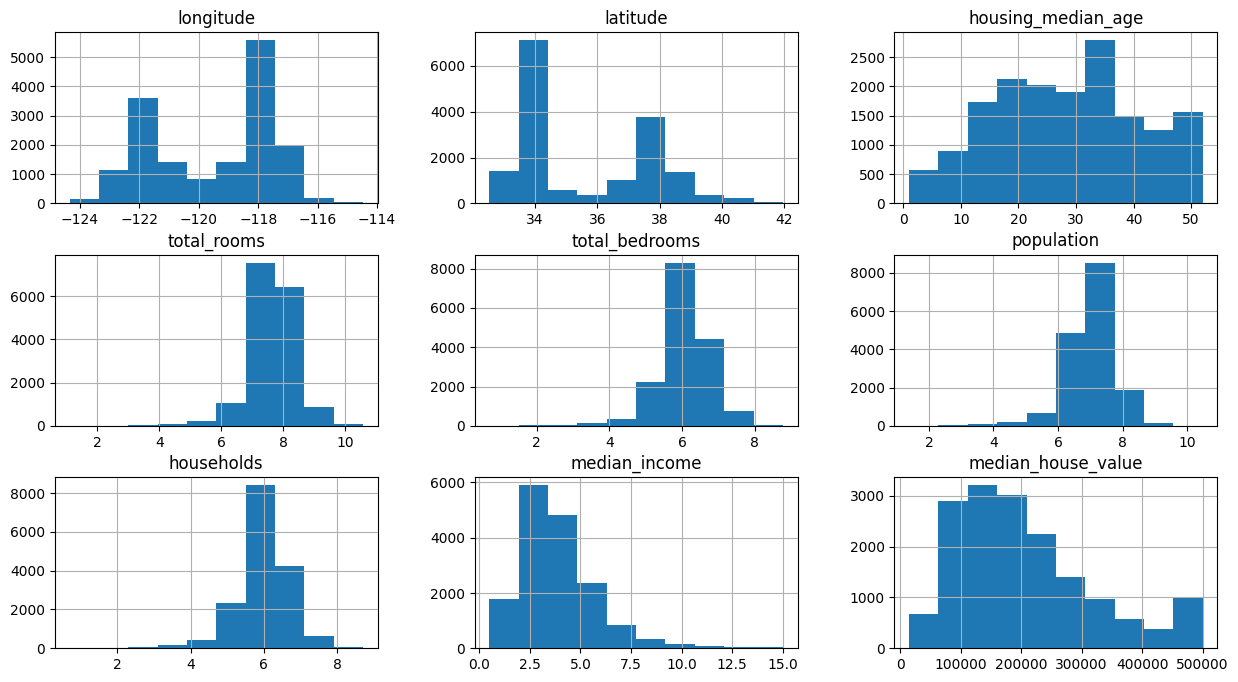

In [13]:
train_data.hist(figsize=(15,8))

In [14]:
# dummy_columns = pd.get_dummies(train_data['ocean_proximity'])
# train_data = train_data.join(dummy_columns)
# train_data = train_data.drop('ocean_proximity', axis=1)
# train_data

In [15]:
# plt.figure(figsize=(15,8))
# # numeric_data = train_data.select_dtypes(include=['int64','float64'])

# sns.heatmap(train_data.corr().round(2), annot=True, cmap='YlGnBu')

<Axes: xlabel='latitude', ylabel='longitude'>

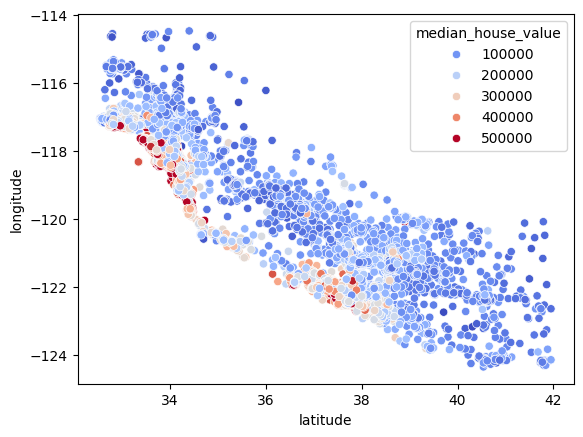

In [16]:
plt.Figure(figsize=(15,8))
sns.scatterplot(x='latitude', y='longitude', data=train_data, hue='median_house_value', palette='coolwarm')

In [17]:
train_data['bedroom_ratio']=train_data['total_bedrooms']/train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms']/train_data['households']

In [18]:
# plt.figure(figsize=(15,8))
# sns.heatmap(train_data.corr().round(2), annot=True, cmap='YlGnBu')

In [19]:
# from sklearn.linear_model import LinearRegression
# x_train,y_train = train_data.drop(['median_house_value'], axis=1), train_data['median_house_value']
# reg = LinearRegression()
# reg.fit(x_train, y_train)

In [20]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

dummy_columns = pd.get_dummies(test_data['ocean_proximity'])
test_data = test_data.join(dummy_columns)
test_data = test_data.drop('ocean_proximity', axis=1)


test_data['bedroom_ratio']=test_data['total_bedrooms']/test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms']/test_data['households']

x_test,y_test = test_data.drop(['median_house_value'], axis=1), test_data['median_house_value']


In [21]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
14416,-117.24,32.79,20.0,6.869014,5.631212,6.265301,5.541264,3.1838,245800.0,False,False,False,False,True,0.819799,1.239612
16383,-121.29,38.01,2.0,8.764678,7.018402,8.110127,6.864848,4.4871,137900.0,False,True,False,False,False,0.800760,1.276748
7731,-118.14,33.92,31.0,8.224700,6.749931,7.746733,6.687109,3.2237,218200.0,True,False,False,False,False,0.820690,1.229934
1410,-122.07,37.94,30.0,7.139660,5.624018,6.562444,5.402677,2.8920,220800.0,False,False,False,True,False,0.787715,1.321504
1335,-121.89,37.99,4.0,7.683404,6.393591,6.834109,6.135565,4.1016,170500.0,False,True,False,False,False,0.832130,1.252273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8291,-118.15,33.76,36.0,7.978311,6.666957,7.076654,6.620073,3.5985,500001.0,False,False,False,False,True,0.835635,1.205170
6274,-117.95,34.03,33.0,7.486053,5.978886,7.325149,5.932245,3.3389,157900.0,True,False,False,False,False,0.798670,1.261926
2997,-119.03,35.32,12.0,7.909122,6.309918,7.166266,6.261492,2.5575,100200.0,False,True,False,False,False,0.797803,1.263137
13440,-117.42,34.08,28.0,7.741099,6.040255,7.180070,6.098074,3.4844,127700.0,False,True,False,False,False,0.780284,1.269433


In [22]:
# reg.score(x_test,y_test)

In [23]:
# from sklearn.ensemble import RandomForestRegressor

# forest =RandomForestRegressor()

# forest.fit(x_train,y_train)

In [24]:
# forest.score(x_test,y_test)

#### hyperparameter tuning

In [25]:
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'n_estimators':[3,10,30],
#     'max_features':[2,4,6,8]
# }

# grid_search = GridSearchCV(forest, param_grid, cv=5, 
#                            scoring='neg_mean_squared_error',
#                            return_train_score=True)
# grid_search.fit(x_train,y_train)

In [26]:
# print(grid_search.best_score_)
# print(grid_search.best_params_)
# best_rf = grid_search.best_estimator_

In [27]:
# best_rf.fit(x_train, y_train)

# best_rf.score(x_test, y_test)

In [28]:
# from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error

# y_pred = grid_search.best_estimator_.predict(x_test)

# print('r2: ', r2_score(y_test, y_pred))
# print('rmse: ', np.sqrt(mean_squared_error(y_test, y_pred)))
# print('mae: ', mean_absolute_error(y_test, y_pred))

In [29]:
corr_target = data.select_dtypes(include=np.number).corr()['median_house_value'].sort_values(ascending=False)
corr_target

median_house_value    1.000000
median_income         0.688355
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
population           -0.025300
longitude            -0.045398
latitude             -0.144638
Name: median_house_value, dtype: float64

In [30]:
# column split
numeric_feature = x.select_dtypes(include=['int64','float64']).columns
categircal_feature = x.select_dtypes(include=['object']).columns

In [31]:
from sklearn.model_selection import train_test_split , GridSearchCV , RandomizedSearchCV , cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_transformer = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',StandardScaler())
    ]
)

cat_transformer = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numeric_feature),
        ('cat', cat_transformer, categircal_feature)
    ]
)


In [32]:

x_train , x_test, y_train , y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
reg_lr = LinearRegression()
from xgboost import XGBRegressor

reg_rf = XGBRegressor(
    n_estimators=100,
    max_depth=10,
    device='cuda',
    tree_method='hist'
)

reg_gb = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    device='cuda',
    tree_method='hist'
)

In [34]:
from sklearn.ensemble import VotingRegressor,StackingRegressor
from sklearn.linear_model import Ridge
voting_reg = VotingRegressor(
    estimators=[
        ('lr',reg_lr),
        ('rf',reg_rf),
        ('gb',reg_gb)
    ]
)

stacking_reg = StackingRegressor(
    estimators=[
        ('rf',reg_rf),
        ('gb',reg_gb)
    ],
    final_estimator=Ridge()
)

In [35]:

# model training
model_to_train = {
    'LinearRegression' : reg_lr,
    'RandomForestRegressor':reg_rf,
    'GradientBoostingRegressor':reg_gb,
    'VotingRegressor':voting_reg,
    'StackingRegressor':stacking_reg
}

In [36]:
# matrics
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
results=[]
for name,model in model_to_train.items():
    pipe = Pipeline(
        [
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )
    
    pipe.fit(x_train,y_train)
    
    y_pred = pipe.predict(x_test)
    
    #evaluate
    r2=r2_score(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Model':name,
        'R2':r2,
        'RMSE':rmse,
        'MAE':mae
        
    })
    
results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
results_df

c:\Users\Tanvir Ishrak\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:751: UserWarning: [06:32:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


,Model,R2,RMSE,MAE
4,StackingRegressor,0.841872,46501.859575,30454.417240
2,GradientBoostingRegressor,0.832582,47848.406039,31795.480204
1,RandomForestRegressor,0.825981,48782.567152,31773.546540
3,VotingRegressor,0.817595,49944.125442,33664.598267
0,LinearRegression,0.648840,69297.716691,50413.433308


In [37]:
best_model_name = results_df.iloc[0]['Model']
best_model_obj = model_to_train[best_model_name]
best_model_obj

,estimators,"[('rf', ...), ('gb', ...)]"
,final_estimator,Ridge()
,cv,None
,n_jobs,None
,passthrough,False
,verbose,0
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None


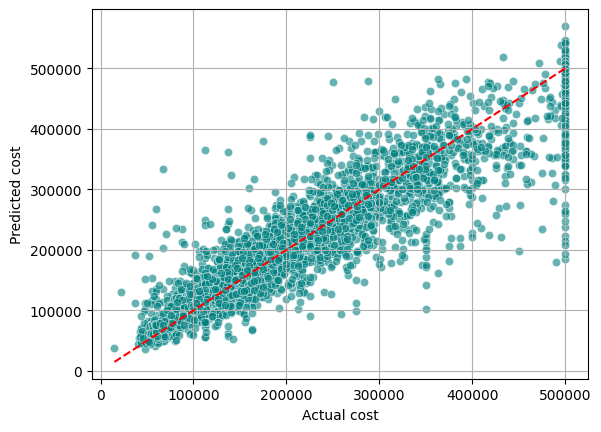

In [38]:
# fit the final model
final_pipe = Pipeline(
        [
            ('preprocessor', preprocessor),
            ('model', best_model_obj)
        ]
    )

final_pipe.fit(x_train,y_train)
y_final_pipe_pred = final_pipe.predict(x_test)


# plot actual vs predicted
plt.Figure(figsize=(8,6))
sns.scatterplot(x=y_test , y=y_final_pipe_pred , alpha=0.6 , color='teal')
plt.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
         color='red', linestyle='--')
plt.xlabel('Actual cost')
plt.ylabel('Predicted cost')
plt.grid(True)
plt.show()

In [39]:
# cross validation

# from sklearn.model_selection import cross_val_score

cv_pipe = Pipeline(
    [
            ('preprocessor', preprocessor),
            ('model', best_model_obj)
        ]
)

cv_score = cross_val_score(cv_pipe , x_train, y_train, cv=5 , scoring='neg_mean_squared_error')
cv_score_rmse= np.sqrt(-cv_score)
print('Score: ', cv_score_rmse)
print('Mean score: ', cv_score_rmse.mean())
print('Std: ',cv_score_rmse.std())

Score:  [44019.04543331 49700.68897679 45172.71501094 47007.59773969
 46463.61532336]
Mean score:  46472.732496817385
Std:  1919.1921559189036


In [41]:
# Hyperparameter tuning

tuning_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', best_model_obj)
])

param_grid = {
    'model__rf__n_estimators':[50,100],
    'model__rf__max_depth':[10,20],

    'model__gb__n_estimators':[50,100],
    'model__gb__max_depth':[3,5],

    'model__final_estimator__alpha':[0.1,1]
}

rand_search = RandomizedSearchCV(
    tuning_pipe,
    param_grid,
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)

x_small = x_train.sample(5000, random_state=42)
y_small = y_train.loc[x_small.index]

rand_search.fit(x_small, y_small)
# rand_search.fit(x_train, y_train)

print(rand_search.best_score_)
print(rand_search.best_params_)
print(rand_search.best_estimator_)

-51475.44244637488
{'model__rf__n_estimators': 100, 'model__rf__max_depth': 10, 'model__gb__n_estimators': 100, 'model__gb__max_depth': 5, 'model__final_estimator__alpha': 0.1}
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                       

In [42]:
# final evaluation 
y_pred = rand_search.best_estimator_.predict(x_test)

print('r2: ', r2_score(y_test, y_pred))
print('rmse: ', np.sqrt(mean_squared_error(y_test, y_pred)))
print('mae: ', mean_absolute_error(y_test, y_pred))

r2:  0.8065716812322585
rmse:  51431.18925603724
mae:  33956.35454929502


In [45]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cat_cols = ['ocean_proximity']
num_cols = x_train.drop(columns=cat_cols).columns

preprocessor = ColumnTransformer([
    ('num','passthrough',num_cols),
    ('cat',OneHotEncoder(handle_unknown='ignore'),cat_cols)
])

x_train2 = preprocessor.fit_transform(x_train)
x_test2 = preprocessor.transform(x_test)

model.fit(x_train2,y_train)
model.score(x_test2,y_test)

0.841872441926042